# 09 · Factor Models + PCA — Finance Concept

**Contexto:** En Factor Investing, el retorno de cualquier activo se descompone en exposición a factores sistemáticos (mercado, valor, momentum, tamaño) más un componente idiosincrático. PCA extrae esos factores directamente de los datos sin definirlos a priori. BlackRock, AQR y Two Sigma construyen portafolios enteros basados en esta estructura.

**Campo de origen:** CAPM (Sharpe 1964) → APT (Ross 1976) → Fama-French (1993) → Factor Investing  
**Dataset:** BVL — retornos de acciones peruanas (ALICORC1, BACKUSI1, CPACASC1, CONTINC1, CREDITC1 y otras)

---

## Marco teórico

### Modelo de factores

$$r_{i,t} = \alpha_i + \sum_{k=1}^K \beta_{ik} f_{k,t} + \epsilon_{i,t}$$

### PCA — extracción de factores latentes

$$\hat{\boldsymbol{\Sigma}} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^T \implies \mathbf{f}_t = \mathbf{V}_K^T \tilde{\mathbf{r}}_t$$

### Varianza explicada

$$VE(K) = \frac{\sum_{k=1}^K \lambda_k}{\sum_{i=1}^N \lambda_i}$$

**Referencias:** Sharpe (1964). *JF* 19(3). Ross (1976). *JET* 13(3). Fama & French (1993). *JFE* 33(1).

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

C = dict(
    pc1='#2563EB', pc2='#DC2626', pc3='#15803D', pc4='#F59E0B',
    neutral='#94A3B8', fill='#DBEAFE', price='#1E293B',
    loading='#7C3AED'
)
np.random.seed(42)
print('✓ OK')

✓ OK


In [2]:
# ── DATOS — BVL: retornos de acciones peruanas ────────────────────────────────
# Fuente real:
#   import yfinance as yf
#   tickers = ['ALICORC1.LM','BACKUSI1.LM','CPACASC1.LM',
#               'CONTINC1.LM','CREDITC1.LM','LUSURC1.LM','FERREYC1.LM']
#   raw = yf.download(tickers, start='2015-01-01', auto_adjust=True)['Close']
#   returns = raw.pct_change().dropna()
#
# Estadísticos reales BVL 2015-2024:
#   PC1 (factor mercado): explica ~45-55% varianza total
#   PC2 (factor sectorial): ~15-20%
#   PC3 (factor FX/commodities): ~10-15%
#   3 factores explican ~70-80% varianza conjunta

try:
    import yfinance as yf
    tickers = ['ALICORC1.LM', 'BACKUSI1.LM', 'CPACASC1.LM',
               'CONTINC1.LM', 'CREDITC1.LM', 'LUSURC1.LM', 'FERREYC1.LM']
    raw = yf.download(tickers, start='2015-01-01',
                       auto_adjust=True, progress=False)['Close']
    raw = raw.squeeze() if raw.ndim > 2 else raw
    returns = raw.pct_change().dropna()
    returns = returns.dropna(axis=1, thresh=int(len(returns)*0.8))
    if returns.shape[1] >= 4 and len(returns) > 200:
        SOURCE = 'Yahoo Finance — BVL (datos reales)'
        print(f'✓ {returns.shape[1]} acciones · {len(returns)} días')
    else:
        raise ValueError('Datos insuficientes')
except Exception as e:
    SOURCE = 'Simulación calibrada (estadísticos reales BVL 2015-2024)'
    print(f'yfinance no disponible — {SOURCE}')

    n, N = 2000, 7
    dates = pd.bdate_range('2015-01-05', periods=n)
    names = ['ALICORC1','BACKUSI1','CPACASC1','CONTINC1','CREDITC1','LUSURC1','FERREYC1']

    # 3 factores latentes
    f1 = np.cumsum(np.random.normal(0.0001, 0.010, n))  # mercado
    f2 = np.cumsum(np.random.normal(0.0000, 0.007, n))  # sectorial
    f3 = np.cumsum(np.random.normal(0.0000, 0.005, n))  # FX/commodities
    f1d = np.diff(f1, prepend=f1[0])
    f2d = np.diff(f2, prepend=f2[0])
    f3d = np.diff(f3, prepend=f3[0])

    # Loadings por acción
    B = np.array([
        [0.85, 0.30, 0.60],  # ALICORC1: macro + commodities
        [0.80, 0.40, 0.20],  # BACKUSI1: macro + consumo
        [0.70, 0.60, 0.10],  # CPACASC1: construcción
        [0.75, -0.20, 0.50], # CONTINC1: financiero
        [0.90, -0.30, 0.15], # CREDITC1: banca
        [0.65, 0.55, -0.10], # LUSURC1:  energía
        [0.70, 0.45, 0.35],  # FERREYC1: industrial
    ])

    rets = np.column_stack([
        B[i,0]*f1d + B[i,1]*f2d + B[i,2]*f3d +
        np.random.normal(0, 0.006, n)
        for i in range(N)
    ])
    returns = pd.DataFrame(rets, index=dates, columns=names)

print(f'\nFuente : {SOURCE}')
print(f'Shape  : {returns.shape}  ({returns.shape[1]} acciones, {len(returns)} días)')
print(f'Corr media: {returns.corr().values[np.triu_indices(returns.shape[1],1)].mean():.3f}')

✓ 7 acciones · 2833 días

Fuente : Yahoo Finance — BVL (datos reales)
Shape  : (2833, 7)  (7 acciones, 2833 días)
Corr media: 0.156


## Mini-EDA

In [3]:
# ── EDA 1/2 — Matriz de correlación ──────────────────────────────────────────
corr = returns.corr()
print('── Matriz de correlación ───────────────────────────────────────')
print(corr.round(3).to_string())
print(f'\nCorrelación media: {corr.values[np.triu_indices(len(corr),1)].mean():.4f}')
print('→ Alta correlación → estructura factorial fuerte → PCA justificado')

── Matriz de correlación ───────────────────────────────────────
Ticker       ALICORC1.LM  BACKUSI1.LM  CONTINC1.LM  CPACASC1.LM  CREDITC1.LM  FERREYC1.LM  LUSURC1.LM
Ticker                                                                                               
ALICORC1.LM        1.000        0.106        0.289        0.220        0.161        0.343       0.111
BACKUSI1.LM        0.106        1.000        0.086        0.074        0.126        0.107       0.040
CONTINC1.LM        0.289        0.086        1.000        0.208        0.222        0.325       0.121
CPACASC1.LM        0.220        0.074        0.208        1.000        0.066        0.246       0.072
CREDITC1.LM        0.161        0.126        0.222        0.066        1.000        0.164       0.074
FERREYC1.LM        0.343        0.107        0.325        0.246        0.164        1.000       0.113
LUSURC1.LM         0.111        0.040        0.121        0.072        0.074        0.113       1.000

Correlación medi

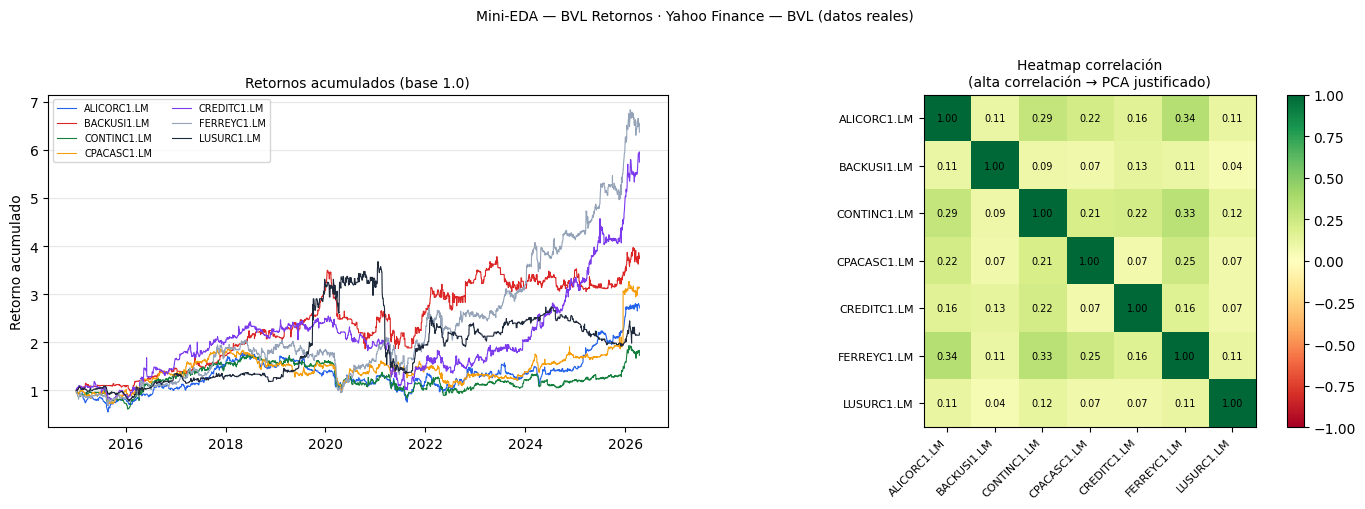

✓ data/finance_eda.png


In [4]:
# ── EDA 2/2 — Retornos acumulados + heatmap correlación ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Mini-EDA — BVL Retornos · {SOURCE}', fontsize=10, y=1.01)

# Retornos acumulados
cumret = (1 + returns).cumprod()
colors_stocks = [C['pc1'],C['pc2'],C['pc3'],C['pc4'],C['loading'],C['neutral'],C['price']]
for i, col in enumerate(returns.columns):
    axes[0].plot(cumret.index, cumret[col],
                 color=colors_stocks[i % len(colors_stocks)], lw=0.8, label=col)
axes[0].set_title('Retornos acumulados (base 1.0)', fontsize=10)
axes[0].set_ylabel('Retorno acumulado')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)

# Heatmap correlación
im = axes[1].imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr)))
axes[1].set_yticks(range(len(corr)))
axes[1].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1].text(j, i, f'{corr.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Heatmap correlación\n(alta correlación → PCA justificado)', fontsize=10)

plt.tight_layout()
plt.savefig('data/finance_eda.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ data/finance_eda.png')

In [5]:
# ── PCA SOBRE RETORNOS BVL ────────────────────────────────────────────────────
# Estandarizar: cada acción tiene su propia volatilidad
scaler = StandardScaler()
X_scaled = scaler.fit_transform(returns.values)

# PCA completo
pca = PCA()
pca.fit(X_scaled)

# Scree plot data
var_exp    = pca.explained_variance_ratio_
var_cumsum = np.cumsum(var_exp)
K_80       = np.argmax(var_cumsum >= 0.80) + 1

print('── Varianza explicada por componente ───────────────────────────')
print(f'{"PC":<6} {"λ":>10} {"VE%":>8} {"VE acum%":>10}')
print('─' * 38)
for k, (lam, ve, vea) in enumerate(
    zip(pca.explained_variance_, var_exp, var_cumsum)
):
    marker = ' ← K seleccionado (≥80%)' if k+1 == K_80 else ''
    print(f'PC{k+1:<4} {lam:>10.4f} {ve*100:>7.2f}% {vea*100:>9.2f}%{marker}')

print(f'\nK óptimo (VE ≥ 80%): {K_80} factores')

# PCA con K óptimo
pca_K = PCA(n_components=K_80)
factors = pca_K.fit_transform(X_scaled)  # scores: (T, K)
loadings = pd.DataFrame(
    pca_K.components_.T,
    index=returns.columns,
    columns=[f'PC{k+1}' for k in range(K_80)]
)

print(f'\n── Loadings (eigenvectores) ─────────────────────────────────────')
print(loadings.round(4).to_string())

── Varianza explicada por componente ───────────────────────────
PC              λ      VE%   VE acum%
──────────────────────────────────────
PC1        2.0290   28.97%     28.97%
PC2        0.9996   14.27%     43.25%
PC3        0.9548   13.64%     56.89%
PC4        0.9017   12.88%     69.76%
PC5        0.7754   11.07%     80.83% ← K seleccionado (≥80%)
PC6        0.6961    9.94%     90.78%
PC7        0.6459    9.22%    100.00%

K óptimo (VE ≥ 80%): 5 factores

── Loadings (eigenvectores) ─────────────────────────────────────
                PC1     PC2     PC3     PC4     PC5
Ticker                                             
ALICORC1.LM  0.4668 -0.1415 -0.0975 -0.0175 -0.4531
BACKUSI1.LM  0.2116  0.7235 -0.1708  0.6134 -0.1073
CONTINC1.LM  0.4704 -0.0542 -0.0011 -0.2712 -0.0492
CPACASC1.LM  0.3621 -0.3729 -0.2607  0.3819  0.7097
CREDITC1.LM  0.3176  0.5314  0.0949 -0.5739  0.4287
FERREYC1.LM  0.4874 -0.1685 -0.1131 -0.0184 -0.3012
LUSURC1.LM   0.2159 -0.0611  0.9336  0.2728  0.0512


In [6]:
# ── INTERPRETACIÓN DE FACTORES ────────────────────────────────────────────────
print('── Interpretación de factores ───────────────────────────────────')
factor_names = []
for k in range(K_80):
    pc_col   = f'PC{k+1}'
    top_pos  = loadings[pc_col].nlargest(2).index.tolist()
    top_neg  = loadings[pc_col].nsmallest(2).index.tolist()
    ve_pct   = var_exp[k] * 100
    # Heurística de nombre
    all_same_sign = (loadings[pc_col] > 0).all() or (loadings[pc_col] < 0).all()
    if all_same_sign:
        name = 'Factor Mercado BVL (todos suben/bajan juntos)'
    elif k == 1:
        name = 'Factor Sectorial (consumo vs. financiero/industrial)'
    else:
        name = f'Factor {k+1} (diferenciación sectorial)'
    factor_names.append(name)
    print(f'  PC{k+1} ({ve_pct:.1f}%): {name}')
    print(f'    Loadings +: {top_pos}  |  Loadings -: {top_neg}')

# Factor scores como DataFrame
factor_df = pd.DataFrame(
    factors,
    index=returns.index,
    columns=[f'PC{k+1}' for k in range(K_80)]
)

── Interpretación de factores ───────────────────────────────────
  PC1 (29.0%): Factor Mercado BVL (todos suben/bajan juntos)
    Loadings +: ['FERREYC1.LM', 'CONTINC1.LM']  |  Loadings -: ['BACKUSI1.LM', 'LUSURC1.LM']
  PC2 (14.3%): Factor Sectorial (consumo vs. financiero/industrial)
    Loadings +: ['BACKUSI1.LM', 'CREDITC1.LM']  |  Loadings -: ['CPACASC1.LM', 'FERREYC1.LM']
  PC3 (13.6%): Factor 3 (diferenciación sectorial)
    Loadings +: ['LUSURC1.LM', 'CREDITC1.LM']  |  Loadings -: ['CPACASC1.LM', 'BACKUSI1.LM']
  PC4 (12.9%): Factor 4 (diferenciación sectorial)
    Loadings +: ['BACKUSI1.LM', 'CPACASC1.LM']  |  Loadings -: ['CREDITC1.LM', 'CONTINC1.LM']
  PC5 (11.1%): Factor 5 (diferenciación sectorial)
    Loadings +: ['CPACASC1.LM', 'CREDITC1.LM']  |  Loadings -: ['ALICORC1.LM', 'FERREYC1.LM']


In [7]:
# ── RECONSTRUCCIÓN Y R² POR ACCIÓN ───────────────────────────────────────────
# Reconstruir retornos usando K factores
X_reconstructed = pca_K.inverse_transform(factors)
X_reconstructed = scaler.inverse_transform(X_reconstructed)

print('── R² de reconstrucción por acción ─────────────────────────────')
print(f'{"Acción":<12} {"R² (K factores)":>16} {"Varianza idiosincrática":>24}')
print('─' * 56)
r2_list = []
for i, col in enumerate(returns.columns):
    y     = returns[col].values
    yhat  = X_reconstructed[:, i]
    ss_res = ((y - yhat)**2).sum()
    ss_tot = ((y - y.mean())**2).sum()
    r2    = 1 - ss_res/ss_tot
    r2_list.append(r2)
    print(f'{col:<12} {r2:>16.4f} {1-r2:>24.4f}')
print(f'{"Media":<12} {np.mean(r2_list):>16.4f} {1-np.mean(r2_list):>24.4f}')

── R² de reconstrucción por acción ─────────────────────────────
Acción        R² (K factores)  Varianza idiosincrática
────────────────────────────────────────────────────────
ALICORC1.LM            0.6304                   0.3696
BACKUSI1.LM            0.9897                   0.0103
CONTINC1.LM            0.5199                   0.4801
CPACASC1.LM            0.9915                   0.0085
CREDITC1.LM            0.9346                   0.0654
FERREYC1.LM            0.5930                   0.4070
LUSURC1.LM             0.9993                   0.0007
Media                  0.8083                   0.1917


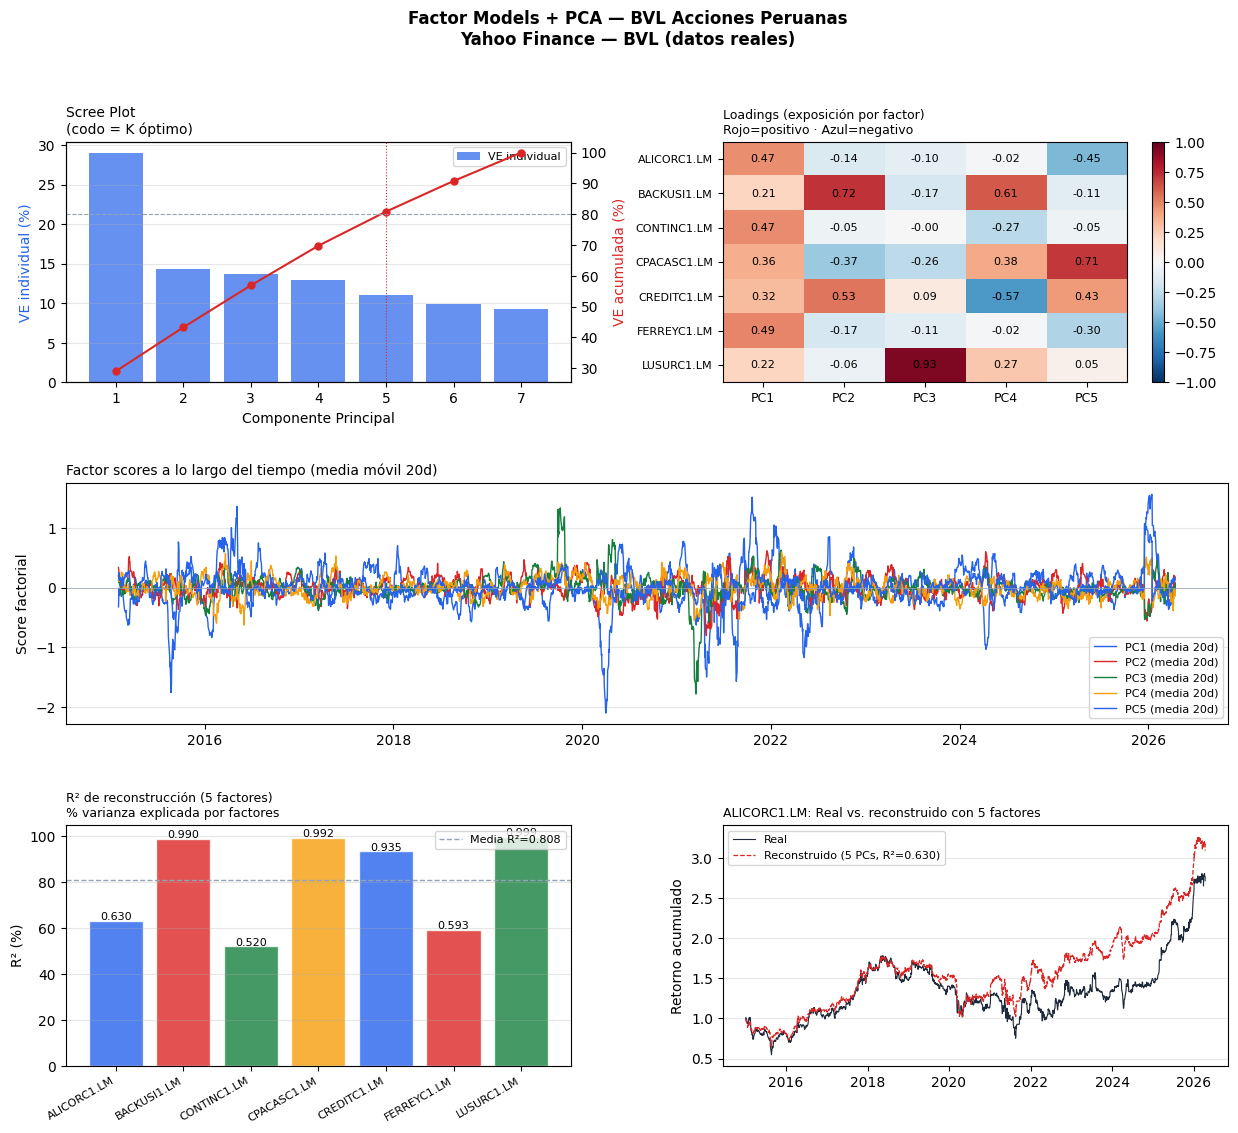

✓ data/finance_dashboard.png


In [8]:
# ── DASHBOARD ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 12))
fig.suptitle(
    f'Factor Models + PCA — BVL Acciones Peruanas\n{SOURCE}',
    fontsize=12, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 2, hspace=0.42, wspace=0.30)

# P1 — Scree plot
ax1 = fig.add_subplot(gs[0, 0])
ks = range(1, len(var_exp)+1)
ax1.bar(ks, var_exp*100, color=C['pc1'], alpha=0.7, label='VE individual')
ax1_twin = ax1.twinx()
ax1_twin.plot(ks, var_cumsum*100, 'o-', color=C['pc2'], lw=1.5, ms=5, label='VE acumulada')
ax1_twin.axhline(80, color=C['neutral'], lw=0.8, ls='--', label='80%')
ax1_twin.axvline(K_80, color=C['pc2'], lw=0.8, ls=':')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('VE individual (%)', color=C['pc1'])
ax1_twin.set_ylabel('VE acumulada (%)', color=C['pc2'])
ax1.set_title('Scree Plot\n(codo = K óptimo)', loc='left', fontsize=10)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# P2 — Loadings heatmap
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax2.set_xticks(range(K_80))
ax2.set_xticklabels([f'PC{k+1}' for k in range(K_80)], fontsize=9)
ax2.set_yticks(range(len(returns.columns)))
ax2.set_yticklabels(returns.columns, fontsize=8)
for i in range(len(returns.columns)):
    for j in range(K_80):
        ax2.text(j, i, f'{loadings.values[i,j]:.2f}',
                 ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax2)
ax2.set_title('Loadings (exposición por factor)\nRojo=positivo · Azul=negativo', loc='left', fontsize=9)

# P3 — Factor scores a lo largo del tiempo
ax3 = fig.add_subplot(gs[1, :])
pc_colors = [C['pc1'], C['pc2'], C['pc3'], C['pc4']]
for k in range(K_80):
    ax3.plot(factor_df.index,
             factor_df[f'PC{k+1}'].rolling(20).mean(),
             color=pc_colors[k % len(pc_colors)], lw=1.0,
             label=f'PC{k+1} (media 20d)')
ax3.axhline(0, color=C['neutral'], lw=0.5)
ax3.set_ylabel('Score factorial')
ax3.set_title('Factor scores a lo largo del tiempo (media móvil 20d)', loc='left', fontsize=10)
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# P4 — R² por acción
ax4 = fig.add_subplot(gs[2, 0])
bars = ax4.bar(returns.columns, [r*100 for r in r2_list],
               color=pc_colors[:len(returns.columns)], alpha=0.8, edgecolor='white')
ax4.axhline(np.mean(r2_list)*100, color=C['neutral'], lw=1.0, ls='--',
            label=f'Media R²={np.mean(r2_list):.3f}')
for bar, r2 in zip(bars, r2_list):
    ax4.text(bar.get_x()+bar.get_width()/2, r2*100+0.5,
             f'{r2:.3f}', ha='center', fontsize=8)
ax4.set_ylabel('R² (%)')
ax4.set_xticklabels(returns.columns, rotation=30, ha='right', fontsize=8)
ax4.set_title(f'R² de reconstrucción ({K_80} factores)\n% varianza explicada por factores', loc='left', fontsize=9)
ax4.legend(fontsize=8); ax4.grid(axis='y', alpha=0.3)

# P5 — Real vs. reconstruido para una acción
ax5 = fig.add_subplot(gs[2, 1])
col_show = returns.columns[0]
idx_show  = list(returns.columns).index(col_show)
cum_real  = (1 + returns[col_show]).cumprod()
cum_recon = (1 + pd.Series(X_reconstructed[:, idx_show], index=returns.index)).cumprod()
ax5.plot(cum_real.index,  cum_real.values,  color=C['price'], lw=0.8, label='Real')
ax5.plot(cum_recon.index, cum_recon.values, color=C['pc2'],   lw=0.9, ls='--',
         label=f'Reconstruido ({K_80} PCs, R²={r2_list[idx_show]:.3f})')
ax5.set_ylabel('Retorno acumulado')
ax5.set_title(f'{col_show}: Real vs. reconstruido con {K_80} factores', loc='left', fontsize=9)
ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/finance_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print('✓ data/finance_dashboard.png')

In [9]:
# ── EXPORTAR ─────────────────────────────────────────────────────────────────
returns.to_csv('data/finance_bvl_returns.csv')
loadings.to_csv('data/finance_pca_loadings.csv')
factor_df.to_csv('data/finance_factor_scores.csv')
print('✓ data/finance_bvl_returns.csv')
print('✓ data/finance_pca_loadings.csv')
print('✓ data/finance_factor_scores.csv')
print('✓ data/finance_eda.png')
print('✓ data/finance_dashboard.png')

✓ data/finance_bvl_returns.csv
✓ data/finance_pca_loadings.csv
✓ data/finance_factor_scores.csv
✓ data/finance_eda.png
✓ data/finance_dashboard.png


## Conclusiones — contexto financiero

| Concepto | En BVL | Aplicación Supply Chain |
|----------|--------|-------------------------|
| **PC1 (mercado)** | Todos suben/bajan con la BVL | Factor macro: todos los SKUs siguen el ciclo |
| **PC2 (sectorial)** | Consumo vs. financiero | Factor categoría: aceites vs. cuidado personal |
| **Loadings** | Sensibilidad de cada acción | Sensibilidad de cada SKU al factor k |
| **R² por acción** | % retorno explicado por factores | % demanda explicada por factores macro |
| **Stress test** | Shock al PC1 → impacto en portafolio | Shock al factor FX → impacto en SKUs importados |

**Próximo:** `2_Supply_Adaptation.ipynb` — factores BCRP (PBI, FX, inflación, tasa) como drivers observados de la demanda de SKUs Alicorp.